Predicting delayed public-service requests to improve municipal response and resource allocation.

In [53]:

import pandas as pd
import requests
from io import StringIO

# load 2019 service requests from the official API
url = "https://data.cityofnewyork.us/resource/76ig-c548.json"


In [54]:
#حجم البيانات كبير جدا وصعب تحميله والبيانات من الحكومة الامريكية وغير موجود في كاقل وهذي طريقه سحب البيانات:
#  i will only upload the 2019 year so i need to make sure all months are listed
all_months = []

for month in range(1, 13):

    start_date = f"2019-{month:02d}-01T00:00:00.000"

    if month == 12:
        end_date = "2020-01-01T00:00:00.000"
    else:
        end_date = f"2019-{month + 1:02d}-01T00:00:00.000"

    params = {
        "$select": "created_date,closed_date,agency,complaint_type,location_type,borough,status",
        "$where": f"created_date >= '{start_date}' AND created_date < '{end_date}'",
        "$limit": 5000 #number of rows
    }
     #get the month data from the website using json
    month_data = pd.DataFrame(requests.get(url, params=params).json())
    all_months.append(month_data)

#join all months in one dataframe
governance_data = pd.concat(all_months, ignore_index=True)

In [55]:
governance_data.shape

(60000, 7)

In [56]:
governance_data.head()

,created_date,closed_date,agency,complaint_type,location_type,borough,status
0,2019-01-01T00:00:00.000,2019-01-10T00:00:00.000,DOHMH,Rodent,3+ Family Apt. Building,QUEENS,Closed
1,2019-01-01T00:00:00.000,2019-01-01T00:00:00.000,DOHMH,Rodent,3+ Family Apt. Building,BRONX,Closed
2,2019-01-01T00:00:00.000,2019-01-02T00:00:00.000,DOHMH,Rodent,3+ Family Apt. Building,BROOKLYN,Closed
3,2019-01-01T00:00:00.000,2019-01-14T00:00:00.000,DOHMH,Rodent,1-2 Family Dwelling,QUEENS,Closed
4,2019-01-01T00:00:00.000,2019-01-01T00:00:00.000,DOHMH,Rodent,3+ Family Apt. Building,BRONX,Closed


In [57]:
# والأعمدة اللي اخذناها:

# created_date: وقت تقديم الطلب
# closed_date: وقت اغلاق الطلب
# agency: الجهة الحكومية
# complaint_type: نوع المشكلة
# location_type: نوع المكان
# borough: المنطقة
# status: حالة الطلب

In [58]:
#convert to datetime
governance_data["created_date"] = pd.to_datetime(governance_data["created_date"])
governance_data["closed_date"] = pd.to_datetime(governance_data["closed_date"])



In [59]:
print(governance_data["created_date"].min())
print(governance_data["created_date"].max())

2019-01-01 00:00:00
2019-12-01 21:38:55


In [60]:
### data cleaning


In [61]:
governance_data.isna().sum()

,0
created_date,0
closed_date,779
agency,0
complaint_type,0
location_type,13239
borough,14
status,0


In [62]:
#remove rows missing important information
governance_data = governance_data.dropna(subset=["created_date", "closed_date", "agency", "complaint_type", "borough"]).copy()

In [63]:
# replace missing location with Unknown
governance_data["location_type"] = governance_data["location_type"].fillna("Unknown")

In [64]:

governance_data.isna().sum()

,0
created_date,0
closed_date,0
agency,0
complaint_type,0
location_type,0
borough,0
status,0


In [65]:
governance_data.duplicated().sum()

np.int64(2440)

In [66]:
## drop repeated rows
governance_data = governance_data.drop_duplicates().copy()

In [67]:
governance_data.shape

(56767, 7)

In [68]:
## eda

#calculate how many hours every request took
governance_data["resolution_hours"] = (governance_data["closed_date"] - governance_data["created_date"]).dt.total_seconds() / 3600

In [69]:
governance_data.head()

,created_date,closed_date,agency,complaint_type,location_type,borough,status,resolution_hours
0,2019-01-01,2019-01-10,DOHMH,Rodent,3+ Family Apt. Building,QUEENS,Closed,216.0
1,2019-01-01,2019-01-01,DOHMH,Rodent,3+ Family Apt. Building,BRONX,Closed,0.0
2,2019-01-01,2019-01-02,DOHMH,Rodent,3+ Family Apt. Building,BROOKLYN,Closed,24.0
3,2019-01-01,2019-01-14,DOHMH,Rodent,1-2 Family Dwelling,QUEENS,Closed,312.0
5,2019-01-01,2019-01-08,DOHMH,Unsanitary Pigeon Condition,1-2 Family Mixed Use Building,BROOKLYN,Closed,168.0


In [70]:
#check wrong negative hours
(governance_data["resolution_hours"] < 0).sum()

np.int64(456)

In [71]:
#remove it
governance_data = governance_data[governance_data["resolution_hours"] >= 0].copy()

In [72]:
governance_data["resolution_hours"].describe()

,resolution_hours
count,56311.000000
mean,753.591097
std,4410.774051
min,0.000000
25%,3.658056
50%,33.733333
75%,145.886806
max,55928.773611


In [73]:
## change hours to days to be more readable --> add new column
governance_data["resolution_days"] = (governance_data["resolution_hours"] / 24).round(2)

In [74]:
governance_data.head()

,created_date,closed_date,agency,complaint_type,location_type,borough,status,resolution_hours,resolution_days
0,2019-01-01,2019-01-10,DOHMH,Rodent,3+ Family Apt. Building,QUEENS,Closed,216.0,9.0
1,2019-01-01,2019-01-01,DOHMH,Rodent,3+ Family Apt. Building,BRONX,Closed,0.0,0.0
2,2019-01-01,2019-01-02,DOHMH,Rodent,3+ Family Apt. Building,BROOKLYN,Closed,24.0,1.0
3,2019-01-01,2019-01-14,DOHMH,Rodent,1-2 Family Dwelling,QUEENS,Closed,312.0,13.0
5,2019-01-01,2019-01-08,DOHMH,Unsanitary Pigeon Condition,1-2 Family Mixed Use Building,BROOKLYN,Closed,168.0,7.0


In [75]:
governance_data["resolution_days"].describe()

,resolution_days
count,56311.000000
mean,31.399604
std,183.782247
min,0.000000
25%,0.150000
50%,1.410000
75%,6.080000
max,2330.370000


# 50% from all orders are closed in 1.41 days
# 75% from orders closed in 6.08 days
# the avg closing orders days is 31.4
# the longest request took 2330 day and this consider as an outlier!
# so from this i know i should not rely on mean .. i will use median

In [76]:
print("More than one year:", (governance_data["resolution_days"] > 365).sum())
#long requests

More than one year: 909


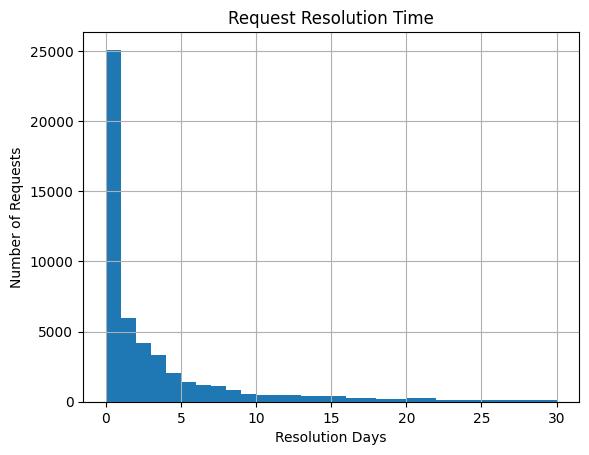

In [77]:
# show the normal resolution days
from matplotlib import pyplot as plt
governance_data[governance_data["resolution_days"] <= 30]["resolution_days"].hist(bins=30)

plt.xlabel("Resolution Days")
plt.ylabel("Number of Requests")
plt.title("Request Resolution Time")
plt.show()

In [ ]:
# most requests closed in the first few days
# only few requests took very long time

In [78]:
# so from the describe() we know 75% of requests is closed in 6 days and we can indicates any request take longer than that will consider long request or delyed

delay_limit = governance_data["resolution_days"].quantile(0.75)


print("Delay limit:", round(delay_limit, 2), "days")


Delay limit: 6.08 days


In [79]:
governance_data["delayed_request"] = (governance_data["resolution_days"] > delay_limit).astype(int)


In [81]:
governance_data["delayed_request"].value_counts()
# 0 means normal and 1 means long resolution time
# 0 --> 6 days or less
# 1 more than 6 days

,count
delayed_request,
0,42248
1,14063


In [83]:
governance_data["delayed_request"].value_counts(normalize=True)*100

,proportion
delayed_request,
0,75.026194
1,24.973806


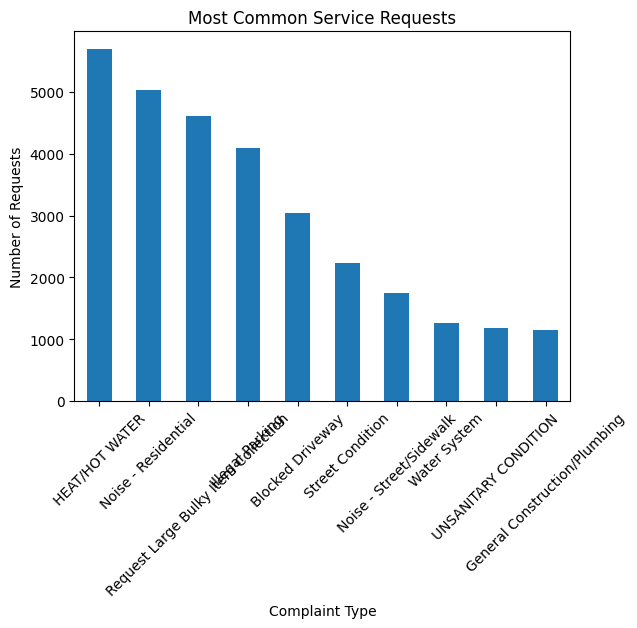

In [84]:
# show the most common request types
governance_data["complaint_type"].value_counts().head(10).plot(kind="bar")

plt.xlabel("Complaint Type")
plt.ylabel("Number of Requests")
plt.title("Most Common Service Requests")
plt.xticks(rotation=45)
plt.show()

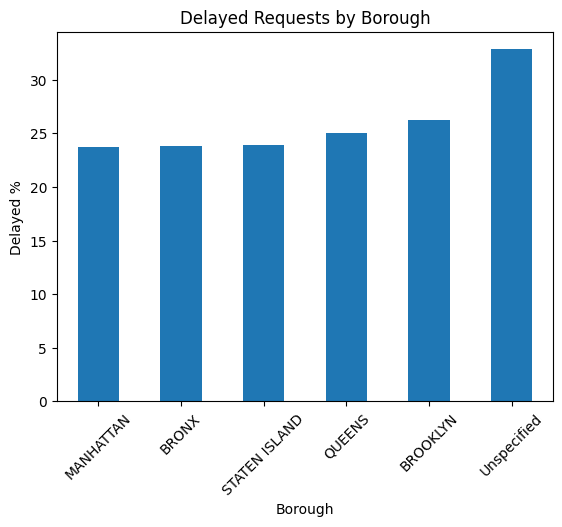

In [86]:
# compare delayed requests between boroughs = neighbrhoods
borough_delay = governance_data.groupby("borough")["delayed_request"].mean()*100

borough_delay.sort_values().plot(kind="bar")

plt.xlabel("Borough")
plt.ylabel("Delayed %")
plt.title("Delayed Requests by Borough")
plt.xticks(rotation=45)
plt.show()

In [87]:
governance_data.head()

,created_date,closed_date,agency,complaint_type,location_type,borough,status,resolution_hours,resolution_days,delayed_request
0,2019-01-01,2019-01-10,DOHMH,Rodent,3+ Family Apt. Building,QUEENS,Closed,216.0,9.0,1
1,2019-01-01,2019-01-01,DOHMH,Rodent,3+ Family Apt. Building,BRONX,Closed,0.0,0.0,0
2,2019-01-01,2019-01-02,DOHMH,Rodent,3+ Family Apt. Building,BROOKLYN,Closed,24.0,1.0,0
3,2019-01-01,2019-01-14,DOHMH,Rodent,1-2 Family Dwelling,QUEENS,Closed,312.0,13.0,1
5,2019-01-01,2019-01-08,DOHMH,Unsanitary Pigeon Condition,1-2 Family Mixed Use Building,BROOKLYN,Closed,168.0,7.0,1


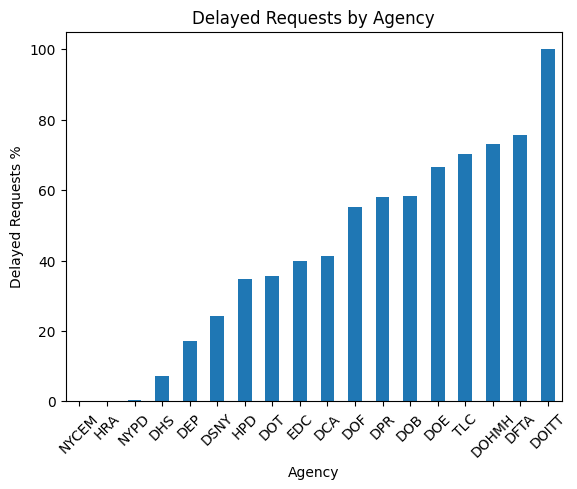

In [88]:
# compare delayed requests between agencies
agency_delay = governance_data.groupby("agency")["delayed_request"].mean() * 100

agency_delay.sort_values().plot(kind="bar")

plt.xlabel("Agency")
plt.ylabel("Delayed Requests %")
plt.title("Delayed Requests by Agency")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# delay rate is different between agencies
# DOITT, DFTA and DOHMH have high delay rates in this sample

In [89]:
governance_data["agency"].value_counts()

,count
agency,
NYPD,17321
HPD,10655
DSNY,9406
DOT,6138
DEP,3692
DOB,2733
DPR,2587
DOHMH,1463
DOF,620


**Feature Engineering**

In [91]:
##sort the data by request date
governance_data = governance_data.sort_values("created_date").reset_index(drop=True)

In [92]:
governance_data["month"] = governance_data["created_date"].dt.month

governance_data["day_of_week"] = governance_data["created_date"].dt.dayofweek

governance_data["hour"] = governance_data["created_date"].dt.hour

governance_data["is_weekend"] = (governance_data["day_of_week"] >= 5).astype(int)



In [93]:
governance_data[["created_date", "month", "day_of_week", "hour", "is_weekend"]].head()


,created_date,month,day_of_week,hour,is_weekend
0,2019-01-01,1,1,0,0
1,2019-01-01,1,1,0,0
2,2019-01-01,1,1,0,0
3,2019-01-01,1,1,0,0
4,2019-01-01,1,1,0,0


In [ ]:
#Encoding

In [94]:
#model features
# these are the  features are shown when a request comes
X = governance_data[
    [
        "agency",
        "complaint_type",
        "location_type",
        "borough",
        "month",
        "day_of_week",
        "hour",
        "is_weekend"
    ]
]

#target
y = governance_data["delayed_request"]

In [95]:
X = pd.get_dummies(X,columns=["agency", "complaint_type", "location_type", "borough"],drop_first=True,dtype=int)

In [96]:
X.shape

(56311, 317)

In [99]:
X.head()

,month,day_of_week,hour,is_weekend,agency_DEP,agency_DFTA,agency_DHS,agency_DOB,agency_DOE,agency_DOF,...,location_type_Unknown,location_type_Vacant Building,location_type_Vacant Lot,location_type_Vacant Lot/Property,location_type_Vehicle Lane,borough_BROOKLYN,borough_MANHATTAN,borough_QUEENS,borough_STATEN ISLAND,borough_Unspecified
0,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [100]:
#column names
X.columns.tolist()

['month',
 'day_of_week',
 'hour',
 'is_weekend',
 'agency_DEP',
 'agency_DFTA',
 'agency_DHS',
 'agency_DOB',
 'agency_DOE',
 'agency_DOF',
 'agency_DOHMH',
 'agency_DOITT',
 'agency_DOT',
 'agency_DPR',
 'agency_DSNY',
 'agency_EDC',
 'agency_HPD',
 'agency_HRA',
 'agency_NYCEM',
 'agency_NYPD',
 'agency_TLC',
 'complaint_type_Abandoned Vehicle',
 'complaint_type_Adopt-A-Basket',
 'complaint_type_Advocate - Other',
 'complaint_type_Advocate-Prop Refunds/Credits',
 'complaint_type_Air Quality',
 'complaint_type_Animal Abuse',
 'complaint_type_Animal in a Park',
 'complaint_type_Animal-Abuse',
 'complaint_type_Asbestos',
 'complaint_type_BEST/Site Safety',
 'complaint_type_Beach/Pool/Sauna Complaint',
 'complaint_type_Benefit Card Replacement',
 'complaint_type_Bike Rack Condition',
 'complaint_type_Bike/Roller/Skate Chronic',
 'complaint_type_Blocked Driveway',
 'complaint_type_Boilers',
 'complaint_type_Borough Office',
 'complaint_type_Bridge Condition',
 'complaint_type_Broken Park

In [101]:
# show borough encoding
X.filter(like="borough").head()

,borough_BROOKLYN,borough_MANHATTAN,borough_QUEENS,borough_STATEN ISLAND,borough_Unspecified
0,0,0,1,0,0
1,1,0,0,0,0
2,0,0,1,0,0
3,0,0,1,0,0
4,0,0,0,0,0


In [102]:
# show agency encoding
X.filter(like="agency").head()

,agency_DEP,agency_DFTA,agency_DHS,agency_DOB,agency_DOE,agency_DOF,agency_DOHMH,agency_DOITT,agency_DOT,agency_DPR,agency_DSNY,agency_EDC,agency_HPD,agency_HRA,agency_NYCEM,agency_NYPD,agency_TLC
0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0


# **Training **

In [ ]:
# IMPORTANT:
# i will not use resolution_days or resolution_hours in the model
# using them will cause data leakage

In [103]:
from sklearn.model_selection import train_test_split

#old requests for training and newer requests for testing
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,shuffle=False)


In [104]:
print(X_train.shape)
print(X_test.shape)

(45048, 317)
(11263, 317)


In [105]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [106]:
#model 1
logistic_model = LogisticRegression(max_iter=1000,class_weight="balanced")

logistic_model.fit(X_train, y_train)
logistic_pred = logistic_model.predict(X_test)

In [107]:
#model 2
tree_model = DecisionTreeClassifier(max_depth=15,class_weight="balanced",random_state=42)

tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

In [108]:
#model 3
forest_model = RandomForestClassifier(n_estimators=100,max_depth=15,class_weight="balanced",random_state=42,n_jobs=-1)

forest_model.fit(X_train, y_train)
forest_pred = forest_model.predict(X_test)

In [112]:
print("Logistic Regression")
print("Accuracy:", round(accuracy_score(y_test, logistic_pred), 2))
print("Precision:", round(precision_score(y_test, logistic_pred), 2))
print("Recall:", round(recall_score(y_test, logistic_pred), 3))
print("F1:", round(f1_score(y_test, logistic_pred), 2))

Logistic Regression
Accuracy: 0.79
Precision: 0.49
Recall: 0.901
F1: 0.63


In [113]:
print("Decision Tree")
print("Accuracy:", round(accuracy_score(y_test, tree_pred), 2))
print("Precision:", round(precision_score(y_test, tree_pred), 2))
print("Recall:", round(recall_score(y_test, tree_pred), 3))
print("F1:", round(f1_score(y_test, tree_pred), 2))

Decision Tree
Accuracy: 0.83
Precision: 0.55
Recall: 0.833
F1: 0.67


In [114]:
print("Random Forest")
print("Accuracy:", round(accuracy_score(y_test, forest_pred), 2))
print("Precision:", round(precision_score(y_test, forest_pred), 2))
print("Recall:", round(recall_score(y_test, forest_pred), 3))
print("F1:", round(f1_score(y_test, forest_pred), 2))

Random Forest
Accuracy: 0.79
Precision: 0.5
Recall: 0.903
F1: 0.64


In [ ]:
## in this project we care about the recall to detect the dalyed requests
# F1 higher
# we will not depend on accuracy alone because 75% from the requests are normal as we saw in the EDA phase

In [ ]:
#  so from the results --> Random Forest is the best one.. selected because recall is most important in this project
# it detected about 90% of the delayed requests
# Decision Tree have better F1 but it missed more delayed requests

## Final Insights

- Most of the public service requests were closed in the first few days.
- Around 75% of the requests were closed in 6 days or less.
- Around 25% of the requests took more than 6 days. We marked these requests as delayed.
- The time to close the request was not the same for all government agencies.
- Some agencies had a high percentage of delayed requests.
- The agency and complaint type were important information for the prediction.
- The borough and location type also helped the model understand the request.
- The month and day of the request can also affect the delay.
- Random Forest found about 90% of the delayed requests.
- We selected Random Forest because finding delayed requests is more important for this project.
- The model can help the city know which requests may take a long time.
- The city can give these requests more attention before the delay become bigger.
- This can help the municipality organize workers and resources better.
- I did not use resolution days and resolution hours in the model.
- These columns use the closed date and already show the final result.
- Using these columns will cause data leakage and give the model an unfair answer.

This model help the city find requests that may delay and give them attention early.